# SwiftCart Week 1 — Quantifying the Bleed

**Submitted by:** SOJOL DAS

**Entry no:** 2025AST2581

**Date:** 3 June 2026

**Objective:**  This EDA quantifies the exact
annualized rupee cost of both errors by store and SKU category, measures the
structural forecasting gap in manual procurement, and establishes the financial
baseline that ML-based demand forecasting must beat.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11


In [2]:
df=pd.read_csv("dataset.csv")
df.head()

,Date,Store_ID,SKU_Category,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales
0,2023-10-01,ST-001,Produce,0.8,2.50,150,110,40,0,0,0
1,2023-10-01,ST-001,Dairy,1.5,3.99,80,80,0,1,1,15
2,2023-10-01,ST-001,Bakery,1.2,4.50,60,45,15,0,0,0
3,2023-10-01,ST-001,Pantry,2.0,5.50,100,95,5,0,0,0
4,2023-10-01,ST-002,Produce,0.8,2.50,120,120,0,1,0,8


In [3]:
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)


Shape: (10, 11)

Column Names: ['Date', 'Store_ID', 'SKU_Category', 'Unit_Cost', 'Retail_Price', 'Units_Ordered', 'Units_Sold', 'Units_Spoiled', 'Stockout_Flag', 'Peak_Hour_Stockout', 'Est_Lost_Sales']

Data Types:
Date                   object
Store_ID               object
SKU_Category           object
Unit_Cost             float64
Retail_Price          float64
Units_Ordered           int64
Units_Sold              int64
Units_Spoiled           int64
Stockout_Flag           int64
Peak_Hour_Stockout      int64
Est_Lost_Sales          int64
dtype: object


In [4]:
df.isnull().sum()

Date                  0
Store_ID              0
SKU_Category          0
Unit_Cost             0
Retail_Price          0
Units_Ordered         0
Units_Sold            0
Units_Spoiled         0
Stockout_Flag         0
Peak_Hour_Stockout    0
Est_Lost_Sales        0
dtype: int64

In [5]:
df.describe().T.style.format("{:.2f}").background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
Unit_Cost,10.00,1.21,0.41,0.80,0.80,1.20,1.50,2.00
Retail_Price,10.00,3.65,1.08,2.50,2.50,3.99,4.37,5.50
Units_Ordered,10.00,108.00,44.42,50.00,82.50,100.00,127.50,200.00
Units_Sold,10.00,94.70,35.93,45.00,76.25,88.50,117.50,160.00
Units_Spoiled,10.00,13.30,15.74,0.00,0.00,10.00,17.25,40.00
Stockout_Flag,10.00,0.40,0.52,0.00,0.00,0.00,1.00,1.00
Peak_Hour_Stockout,10.00,0.30,0.48,0.00,0.00,0.00,0.75,1.00
Est_Lost_Sales,10.00,6.80,9.73,0.00,0.00,0.00,13.25,25.00


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

# Financial columns
df['Wastage_Cost']   = df['Units_Spoiled']  * df['Unit_Cost']
df['Lost_Revenue']   = df['Est_Lost_Sales'] * df['Retail_Price']
df['Gross_Revenue']  = df['Units_Sold']     * df['Retail_Price']
df['Forecast_Error'] = df['Units_Ordered']  - df['Units_Sold']
df['Overstock']      = df['Forecast_Error'].clip(lower=0)
df['Understock']     = (-df['Forecast_Error']).clip(lower=0)

print("New columns added: Wastage_Cost, Lost_Revenue, Gross_Revenue, Forecast_Error, Overstock, Understock")
df[['Date','Store_ID','SKU_Category','Wastage_Cost','Lost_Revenue','Forecast_Error']].head(10)

New columns added: Wastage_Cost, Lost_Revenue, Gross_Revenue, Forecast_Error, Overstock, Understock


,Date,Store_ID,SKU_Category,Wastage_Cost,Lost_Revenue,Forecast_Error
0,2023-10-01,ST-001,Produce,32.0,0.00,40
1,2023-10-01,ST-001,Dairy,0.0,59.85,0
2,2023-10-01,ST-001,Bakery,18.0,0.00,15
3,2023-10-01,ST-001,Pantry,10.0,0.00,5
4,2023-10-01,ST-002,Produce,0.0,20.00,0
5,2023-10-01,ST-002,Dairy,22.5,0.00,15
6,2023-10-01,ST-002,Bakery,0.0,90.00,0
7,2023-10-01,ST-003,Produce,32.0,0.00,40
8,2023-10-02,ST-001,Produce,0.0,62.50,0
9,2023-10-02,ST-001,Dairy,27.0,0.00,18


In [7]:
num_days = df['Date'].nunique()

# --- Loss A: Wastage ---
total_wastage_cost     = df['Wastage_Cost'].sum()
annualized_wastage     = total_wastage_cost * (365 / num_days)

# --- Loss B: Peak-hour stockout revenue loss ---
peak_lost_revenue      = df[df['Peak_Hour_Stockout'] == 1]['Lost_Revenue'].sum()
annualized_stockout    = peak_lost_revenue * (365 / num_days)

# --- Total Bleed ---
total_annualized_bleed = annualized_wastage + annualized_stockout

# --- Revenue context ---
total_gross_revenue    = df['Gross_Revenue'].sum()
annualized_revenue     = total_gross_revenue * (365 / num_days)
bleed_pct              = (total_annualized_bleed / annualized_revenue) * 100

print("=" * 52)
print("        SWIFTCART ANNUALIZED BLEED REPORT")
print("=" * 52)
print(f"  Sample covers         : {num_days} day(s), {len(df)} records")
print(f"  Stores in sample      : {df['Store_ID'].nunique()}")
print("-" * 52)
print(f"  Loss A – Wastage Cost : ₹{annualized_wastage:,.2f}")
print(f"  Loss B – Stockout Rev : ₹{annualized_stockout:,.2f}")
print("-" * 52)
print(f"  TOTAL ANNUALIZED BLEED: ₹{total_annualized_bleed:,.2f}")
print(f"  Annualized Revenue    : ₹{annualized_revenue:,.2f}")
print(f"  Bleed as % of Revenue : {bleed_pct:.2f}%")
print("=" * 52)

        SWIFTCART ANNUALIZED BLEED REPORT
  Sample covers         : 2 day(s), 10 records
  Stores in sample      : 3
----------------------------------------------------
  Loss A – Wastage Cost : ₹25,823.75
  Loss B – Stockout Rev : ₹38,753.88
----------------------------------------------------
  TOTAL ANNUALIZED BLEED: ₹64,577.62
  Annualized Revenue    : ₹583,202.47
  Bleed as % of Revenue : 11.07%


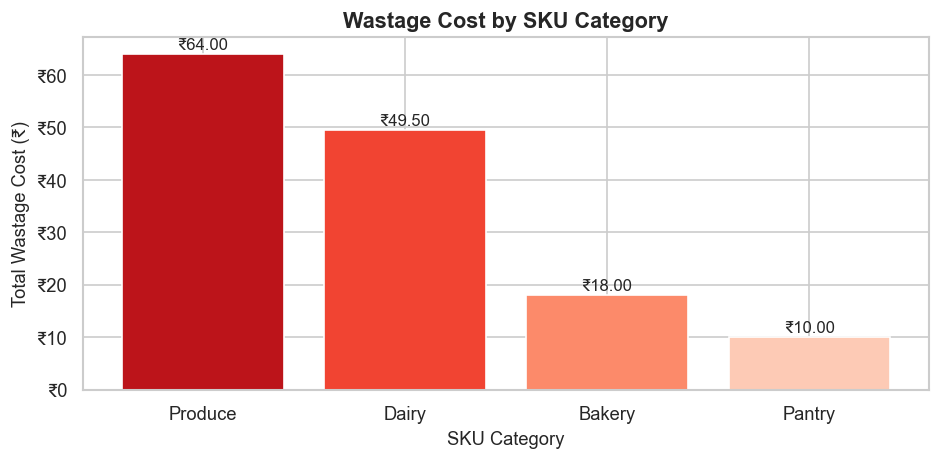


Wastage Cost Breakdown:
              Cost (₹)
SKU_Category          
Produce           64.0
Dairy             49.5
Bakery            18.0
Pantry            10.0


In [8]:
wastage_by_cat = df.groupby('SKU_Category')['Wastage_Cost'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(wastage_by_cat.index, wastage_by_cat.values,
              color=sns.color_palette('Reds_r', len(wastage_by_cat)))

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'₹{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

ax.set_title('Wastage Cost by SKU Category', fontweight='bold')
ax.set_xlabel('SKU Category')
ax.set_ylabel('Total Wastage Cost (₹)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('₹%.0f'))
plt.tight_layout()
plt.show()

print("\nWastage Cost Breakdown:")
print(wastage_by_cat.to_frame().rename(columns={'Wastage_Cost':'Cost (₹)'}))

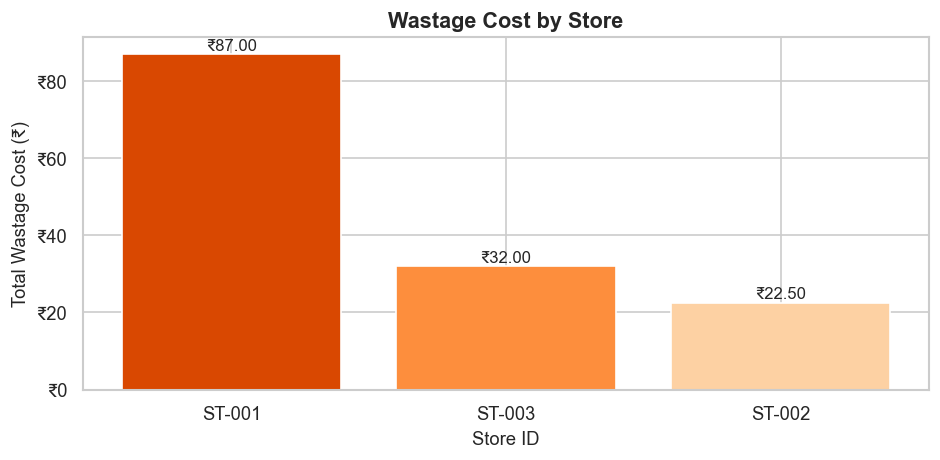

In [9]:
wastage_by_store = df.groupby('Store_ID')['Wastage_Cost'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(wastage_by_store.index, wastage_by_store.values,
              color=sns.color_palette('Oranges_r', len(wastage_by_store)))

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'₹{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

ax.set_title('Wastage Cost by Store', fontweight='bold')
ax.set_xlabel('Store ID')
ax.set_ylabel('Total Wastage Cost (₹)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('₹%.0f'))
plt.tight_layout()
plt.show()

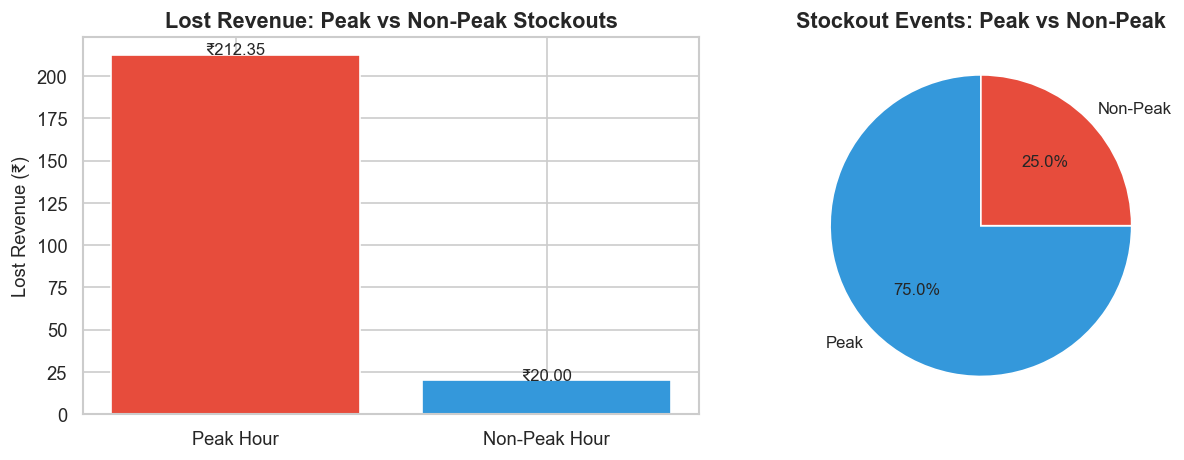


Peak-Hour Lost Revenue    : ₹212.35
Non-Peak Lost Revenue     : ₹20.00
Peak is 91.4% of total lost revenue from stockouts


In [10]:
stockout_df = df[df['Stockout_Flag'] == 1].copy()

peak_rev    = stockout_df[stockout_df['Peak_Hour_Stockout'] == 1]['Lost_Revenue'].sum()
nonpeak_rev = stockout_df[stockout_df['Peak_Hour_Stockout'] == 0]['Lost_Revenue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Chart 1: Lost revenue — peak vs non-peak
labels = ['Peak Hour', 'Non-Peak Hour']
values = [peak_rev, nonpeak_rev]
colors = ['#e74c3c', '#3498db']
axes[0].bar(labels, values, color=colors)
for i, v in enumerate(values):
    axes[0].text(i, v + 0.3, f'₹{v:.2f}', ha='center', fontsize=10)
axes[0].set_title('Lost Revenue: Peak vs Non-Peak Stockouts', fontweight='bold')
axes[0].set_ylabel('Lost Revenue (₹)')

# Chart 2: Count of stockout events
stockout_counts = stockout_df['Peak_Hour_Stockout'].value_counts()
axes[1].pie(stockout_counts.values,
            labels=['Non-Peak', 'Peak'] if stockout_counts.index[0] == 0 else ['Peak', 'Non-Peak'],
            autopct='%1.1f%%', colors=['#3498db','#e74c3c'],
            startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Stockout Events: Peak vs Non-Peak', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nPeak-Hour Lost Revenue    : ₹{peak_rev:.2f}")
print(f"Non-Peak Lost Revenue     : ₹{nonpeak_rev:.2f}")
print(f"Peak is {(peak_rev/(peak_rev+nonpeak_rev+1e-9)*100):.1f}% of total lost revenue from stockouts")

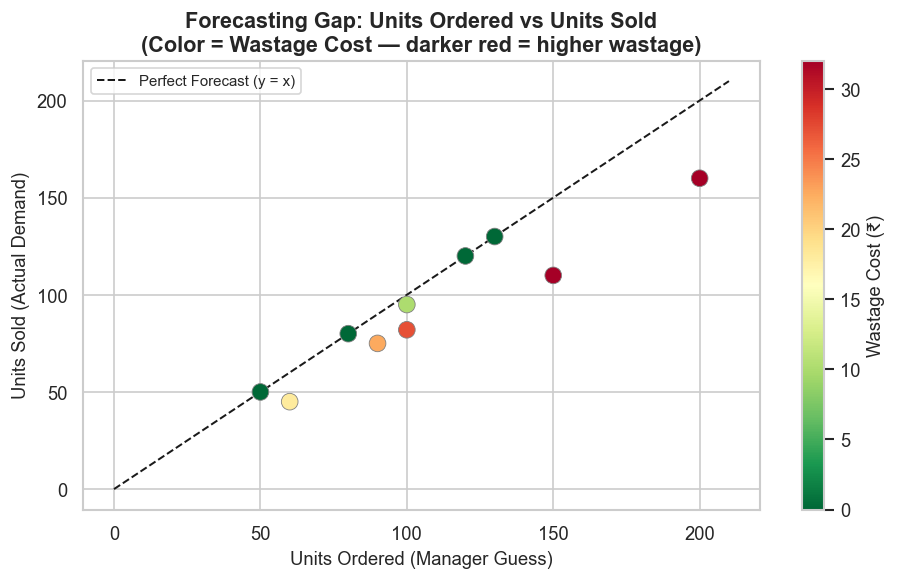


Forecasting Performance:
  Mean Absolute Error (MAE)  : 13.30 units/record
  Mean Bias                  : 13.30 units (positive = chronic overstocking)
  Total Units Overstocked    : 133
  Total Units Understocked   : 0


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['Units_Ordered'], df['Units_Sold'],
           c=df['Wastage_Cost'], cmap='RdYlGn_r',
           s=100, edgecolors='grey', linewidths=0.5, zorder=3)

# Perfect forecast reference line
max_val = max(df['Units_Ordered'].max(), df['Units_Sold'].max()) + 10
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1.2, label='Perfect Forecast (y = x)')

ax.set_title('Forecasting Gap: Units Ordered vs Units Sold\n(Color = Wastage Cost — darker red = higher wastage)', fontweight='bold')
ax.set_xlabel('Units Ordered (Manager Guess)')
ax.set_ylabel('Units Sold (Actual Demand)')
ax.legend(fontsize=9)

sm = plt.cm.ScalarMappable(cmap='RdYlGn_r',
     norm=plt.Normalize(df['Wastage_Cost'].min(), df['Wastage_Cost'].max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Wastage Cost (₹)')

plt.tight_layout()
plt.show()

mae  = df['Forecast_Error'].abs().mean()
bias = df['Forecast_Error'].mean()
print(f"\nForecasting Performance:")
print(f"  Mean Absolute Error (MAE)  : {mae:.2f} units/record")
print(f"  Mean Bias                  : {bias:.2f} units (positive = chronic overstocking)")
print(f"  Total Units Overstocked    : {df['Overstock'].sum()}")
print(f"  Total Units Understocked   : {df['Understock'].sum()}")

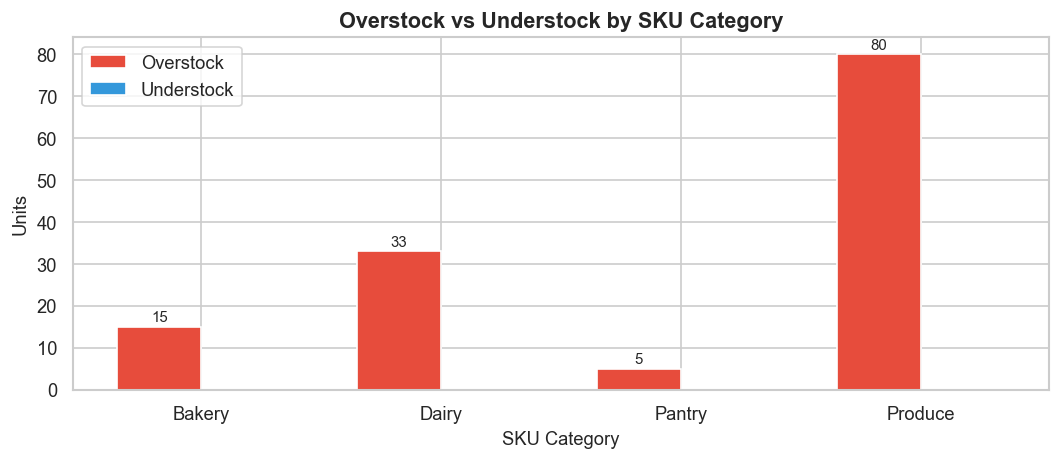

In [12]:
forecast_cat = df.groupby('SKU_Category')[['Overstock','Understock']].sum()

x     = np.arange(len(forecast_cat))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - width/2, forecast_cat['Overstock'],  width, label='Overstock',   color='#e74c3c')
b2 = ax.bar(x + width/2, forecast_cat['Understock'], width, label='Understock',  color='#3498db')

ax.set_title('Overstock vs Understock by SKU Category', fontweight='bold')
ax.set_xlabel('SKU Category')
ax.set_ylabel('Units')
ax.set_xticks(x)
ax.set_xticklabels(forecast_cat.index)
ax.legend()

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                str(int(h)), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
margin_df = df.groupby('SKU_Category').agg(
    Avg_Unit_Cost    = ('Unit_Cost',    'mean'),
    Avg_Retail_Price = ('Retail_Price', 'mean'),
    Total_Revenue    = ('Gross_Revenue','sum'),
    Total_Wastage    = ('Wastage_Cost', 'sum'),
    Total_Lost_Rev   = ('Lost_Revenue', 'sum')
).reset_index()

margin_df['Gross_Margin_%']   = ((margin_df['Avg_Retail_Price'] - margin_df['Avg_Unit_Cost'])
                                  / margin_df['Avg_Retail_Price'] * 100).round(2)
margin_df['Bleed_%_of_Rev']   = ((margin_df['Total_Wastage'] + margin_df['Total_Lost_Rev'])
                                  / margin_df['Total_Revenue'] * 100).round(2)

print("Category-Level Margin & Bleed Summary:")
margin_df.style.format({
    'Avg_Unit_Cost'   : '₹{:.2f}',
    'Avg_Retail_Price': '₹{:.2f}',
    'Total_Revenue'   : '₹{:.2f}',
    'Total_Wastage'   : '₹{:.2f}',
    'Total_Lost_Rev'  : '₹{:.2f}',
    'Gross_Margin_%'  : '{:.2f}%',
    'Bleed_%_of_Rev'  : '{:.2f}%'
}).background_gradient(subset=['Bleed_%_of_Rev'], cmap='Reds')

Category-Level Margin & Bleed Summary:


,SKU_Category,Avg_Unit_Cost,Avg_Retail_Price,Total_Revenue,Total_Wastage,Total_Lost_Rev,Gross_Margin_%,Bleed_%_of_Rev
0,Bakery,₹1.20,₹4.50,₹427.50,₹18.00,₹90.00,73.33%,25.26%
1,Dairy,₹1.50,₹3.99,₹945.63,₹49.50,₹59.85,62.41%,11.56%
2,Pantry,₹2.00,₹5.50,₹522.50,₹10.00,₹0.00,63.64%,1.91%
3,Produce,₹0.80,₹2.50,₹1300.00,₹64.00,₹82.50,68.00%,11.27%


In [14]:
print("=" * 60)
print("          WEEK 1 FINDINGS — EXECUTIVE SUMMARY")
print("=" * 60)

worst_waste_cat   = wastage_by_cat.idxmax()
worst_waste_store = wastage_by_store.idxmax()

print(f"\n1. WASTAGE (Mistake A — Overstocking)")
print(f"   Highest wastage category : {worst_waste_cat} (₹{wastage_by_cat.max():.2f})")
print(f"   Highest wastage store    : {worst_waste_store} (₹{wastage_by_store.max():.2f})")
print(f"   Annualized wastage cost  : ₹{annualized_wastage:,.2f}")

print(f"\n2. STOCKOUTS (Mistake B — Understocking)")
print(f"   Peak-hour revenue lost   : ₹{peak_rev:.2f} in sample")
print(f"   Annualized stockout loss : ₹{annualized_stockout:,.2f}")

print(f"\n3. FORECASTING GAP")
print(f"   Avg manager forecast error (MAE) : {mae:.2f} units/order")
print(f"   Chronic overstock bias           : {bias:.2f} units/order")

print(f"\n4. TOTAL ANNUALIZED BLEED")
print(f"   ₹{total_annualized_bleed:,.2f}  ({bleed_pct:.2f}% of projected revenue)")

print(f"\nCONCLUSION: Manual procurement across {df['Store_ID'].nunique()} stores")
print(f"is structurally incapable of demand prediction at scale.")
print(f"ML-based forecasting is the only viable fix.")
print("=" * 60)

          WEEK 1 FINDINGS — EXECUTIVE SUMMARY

1. WASTAGE (Mistake A — Overstocking)
   Highest wastage category : Produce (₹64.00)
   Highest wastage store    : ST-001 (₹87.00)
   Annualized wastage cost  : ₹25,823.75

2. STOCKOUTS (Mistake B — Understocking)
   Peak-hour revenue lost   : ₹212.35 in sample
   Annualized stockout loss : ₹38,753.88

3. FORECASTING GAP
   Avg manager forecast error (MAE) : 13.30 units/order
   Chronic overstock bias           : 13.30 units/order

4. TOTAL ANNUALIZED BLEED
   ₹64,577.62  (11.07% of projected revenue)

CONCLUSION: Manual procurement across 3 stores
is structurally incapable of demand prediction at scale.
ML-based forecasting is the only viable fix.
